# Hybrid Prophet + LSTM Test Inference

Notebook dùng để load các mô hình Hybrid Prophet + LSTM (.pkl) đã huấn luyện và đánh giá trực tiếp trên toàn bộ tập test. Quy trình:

1. Nạp mô hình đã huấn luyện trong `models/`
2. Chạy dự đoán toàn bộ tập test (không rolling horizon)
3. Đo thời gian infer, tính các metric (MAE, RMSE, MAPE, R²)
4. Vẽ biểu đồ trực quan cho từng target



In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

from model_utils import (
    load_model,
    get_latest_model,
    calculate_metrics,
    print_metrics,
    save_results,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:,.6f}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Libraries imported (device={DEVICE})")


✓ Libraries imported (device=cpu)


In [2]:
# Paths & targets
MODELS_DIR = Path('models')
DATA_DIR = Path('processed_data')
TARGETS = ['memory_usage_pct', 'cpu_total_usage', 'system_load']
MODEL_NAME = 'hybrid_prophet_lstm'
DEFAULT_FREQ = '30S'

MODELS_DIR.mkdir(exist_ok=True)

print("✓ Configuration ready")


✓ Configuration ready


In [3]:
def load_series(target: str):
    target_dir = DATA_DIR / target
    y_train = pd.read_csv(target_dir / 'y_train.csv').squeeze()
    y_test = pd.read_csv(target_dir / 'y_test.csv').squeeze()
    return y_train, y_test


class LSTMResidualModel(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out


def forecast_residuals(model, seed_sequence, n_steps, window_size):
    model.eval()
    seq = seed_sequence.copy().tolist()
    preds = []
    with torch.no_grad():
        for _ in range(n_steps):
            window = torch.tensor(seq[-window_size:], dtype=torch.float32).view(1, window_size, 1).to(DEVICE)
            pred = model(window).cpu().item()
            preds.append(pred)
            seq.append(pred)
    return np.array(preds)


def inverse_scale(values, mean, std):
    return values * std + mean



In [4]:
def resolve_model_paths(model_name: str = MODEL_NAME):
    model_paths = {}
    for target in TARGETS:
        model_paths[target] = get_latest_model(
            models_dir=str(MODELS_DIR),
            model_name=model_name,
            target=target,
        )
    return model_paths


model_paths = resolve_model_paths()
model_paths


Importing plotly failed. Interactive plots will not work.


Latest model: models\hybrid_prophet_lstm_memory_usage_pct_20251125_115803.pkl
Latest model: models\hybrid_prophet_lstm_cpu_total_usage_20251125_121521.pkl
Latest model: models\hybrid_prophet_lstm_system_load_20251125_123017.pkl


{'memory_usage_pct': 'models\\hybrid_prophet_lstm_memory_usage_pct_20251125_115803.pkl',
 'cpu_total_usage': 'models\\hybrid_prophet_lstm_cpu_total_usage_20251125_121521.pkl',
 'system_load': 'models\\hybrid_prophet_lstm_system_load_20251125_123017.pkl'}

In [5]:
evaluation_records = []
detailed_results = {}
prediction_store = {}
evaluation_results = {}

for target in TARGETS:
    print("\n" + "=" * 80)
    print(f"Target: {target}")
    print("=" * 80)

    y_train, y_test = load_series(target)
    model_path = model_paths[target]
    model_bundle, metadata = load_model(model_path)

    prophet_model = model_bundle['prophet']
    lstm_state_dict = model_bundle['lstm_state_dict']
    residual_mean = model_bundle['residual_mean']
    residual_std = model_bundle['residual_std'] if model_bundle['residual_std'] > 0 else 1e-6
    window_size = model_bundle.get('window_size') or model_bundle.get('config', {}).get('lstm', {}).get('window_size', 96)
    freq = model_bundle.get('freq', DEFAULT_FREQ)
    lstm_cfg = model_bundle.get('config', {}).get('lstm', {})

    lstm_model = LSTMResidualModel(
        hidden_size=lstm_cfg.get('hidden_size', 64),
        num_layers=lstm_cfg.get('num_layers', 2),
        dropout=lstm_cfg.get('dropout', 0.1),
    ).to(DEVICE)
    lstm_model.load_state_dict(lstm_state_dict)
    lstm_model.eval()

    n_train = len(y_train)
    n_test = len(y_test)
    total_len = n_train + n_test

    start_time = time.time()

    future_df = prophet_model.make_future_dataframe(periods=n_test, freq=freq)
    forecast_df = prophet_model.predict(future_df)
    prophet_preds = forecast_df['yhat'].values
    prophet_train_pred = prophet_preds[:n_train]
    prophet_test_pred = prophet_preds[-n_test:]

    train_residuals = y_train.values - prophet_train_pred
    residuals_scaled = (train_residuals - residual_mean) / residual_std

    if len(residuals_scaled) < window_size:
        raise ValueError(f"Not enough residual history ({len(residuals_scaled)}) for window_size={window_size}")

    seed_sequence = residuals_scaled[-window_size:]
    residual_test_scaled = forecast_residuals(lstm_model, seed_sequence, n_test, window_size)
    residual_test_pred = inverse_scale(residual_test_scaled, residual_mean, residual_std)
    hybrid_test_pred = prophet_test_pred + residual_test_pred

    runtime = time.time() - start_time
    per_sample_ms = runtime / n_test * 1000

    prophet_metrics = calculate_metrics(y_test.values, prophet_test_pred)
    hybrid_metrics = calculate_metrics(y_test.values, hybrid_test_pred)

    print("Prophet-only metrics:")
    print_metrics(prophet_metrics, target + ' (Prophet)')
    print("Hybrid metrics:")
    print_metrics(hybrid_metrics, target + ' (Hybrid)')
    print(f"  Runtime: {runtime:.2f}s ({per_sample_ms:.3f} ms/sample)")

    evaluation_records.append({
        'target': target,
        'model_path': model_path,
        'samples': n_test,
        'runtime_s': runtime,
        'ms_per_sample': per_sample_ms,
        **hybrid_metrics,
    })

    detailed_results[target] = {
        'model_path': model_path,
        'metadata': metadata,
        'samples': n_test,
        'runtime_seconds': runtime,
        'ms_per_sample': per_sample_ms,
        'prophet_metrics': prophet_metrics,
        'hybrid_metrics': hybrid_metrics,
    }

    prediction_store[target] = {
        'y_true': y_test.values,
        'prophet_pred': prophet_test_pred,
        'hybrid_pred': hybrid_test_pred,
        'residual_pred': residual_test_pred,
    }

    evaluation_results[target] = hybrid_metrics

print("\n✓ Evaluation finished")



Target: memory_usage_pct
✓ Model loaded: models\hybrid_prophet_lstm_memory_usage_pct_20251125_115803.pkl
  Model: hybrid_prophet_lstm
  Target: memory_usage_pct
  Saved at: 2025-11-25 11:58:03
Prophet-only metrics:

Metrics for memory_usage_pct (Prophet):
  MAE:         2.942975
  RMSE:        3.232681
  MAPE:        640.49%
  R²:          -12.347290
  Max Error:   5.490552
  Median AE:   2.771104
Hybrid metrics:

Metrics for memory_usage_pct (Hybrid):
  MAE:         3.055926
  RMSE:        3.337395
  MAPE:        672.51%
  R²:          -13.225993
  Max Error:   5.605828
  Median AE:   2.886380
  Runtime: 86.71s (5.056 ms/sample)

Target: cpu_total_usage
✓ Model loaded: models\hybrid_prophet_lstm_cpu_total_usage_20251125_121521.pkl
  Model: hybrid_prophet_lstm
  Target: cpu_total_usage
  Saved at: 2025-11-25 12:15:21
Prophet-only metrics:

Metrics for cpu_total_usage (Prophet):
  MAE:         0.884480
  RMSE:        1.122104
  MAPE:        245.89%
  R²:          -0.316501
  Max Error:

In [6]:
summary_df = pd.DataFrame(evaluation_records).set_index('target')
summary_df


,model_path,samples,runtime_s,ms_per_sample,mae,rmse,mse,mape,r2,max_error,median_ae
target,,,,,,,,,,,
memory_usage_pct,models\hybrid_prophet_lstm_memory_usage_pct_20...,17150,86.713043,5.056154,3.055926,3.337395,11.138206,672.508119,-13.225993,5.605828,2.886380
cpu_total_usage,models\hybrid_prophet_lstm_cpu_total_usage_202...,17150,80.348568,4.685048,1.544440,1.715171,2.941812,597.327753,-2.075886,13.032090,1.521639
system_load,models\hybrid_prophet_lstm_system_load_2025112...,17150,87.408499,5.096705,0.646504,1.010859,1.021836,368.406446,-0.065681,11.901201,0.558404


## Visualization


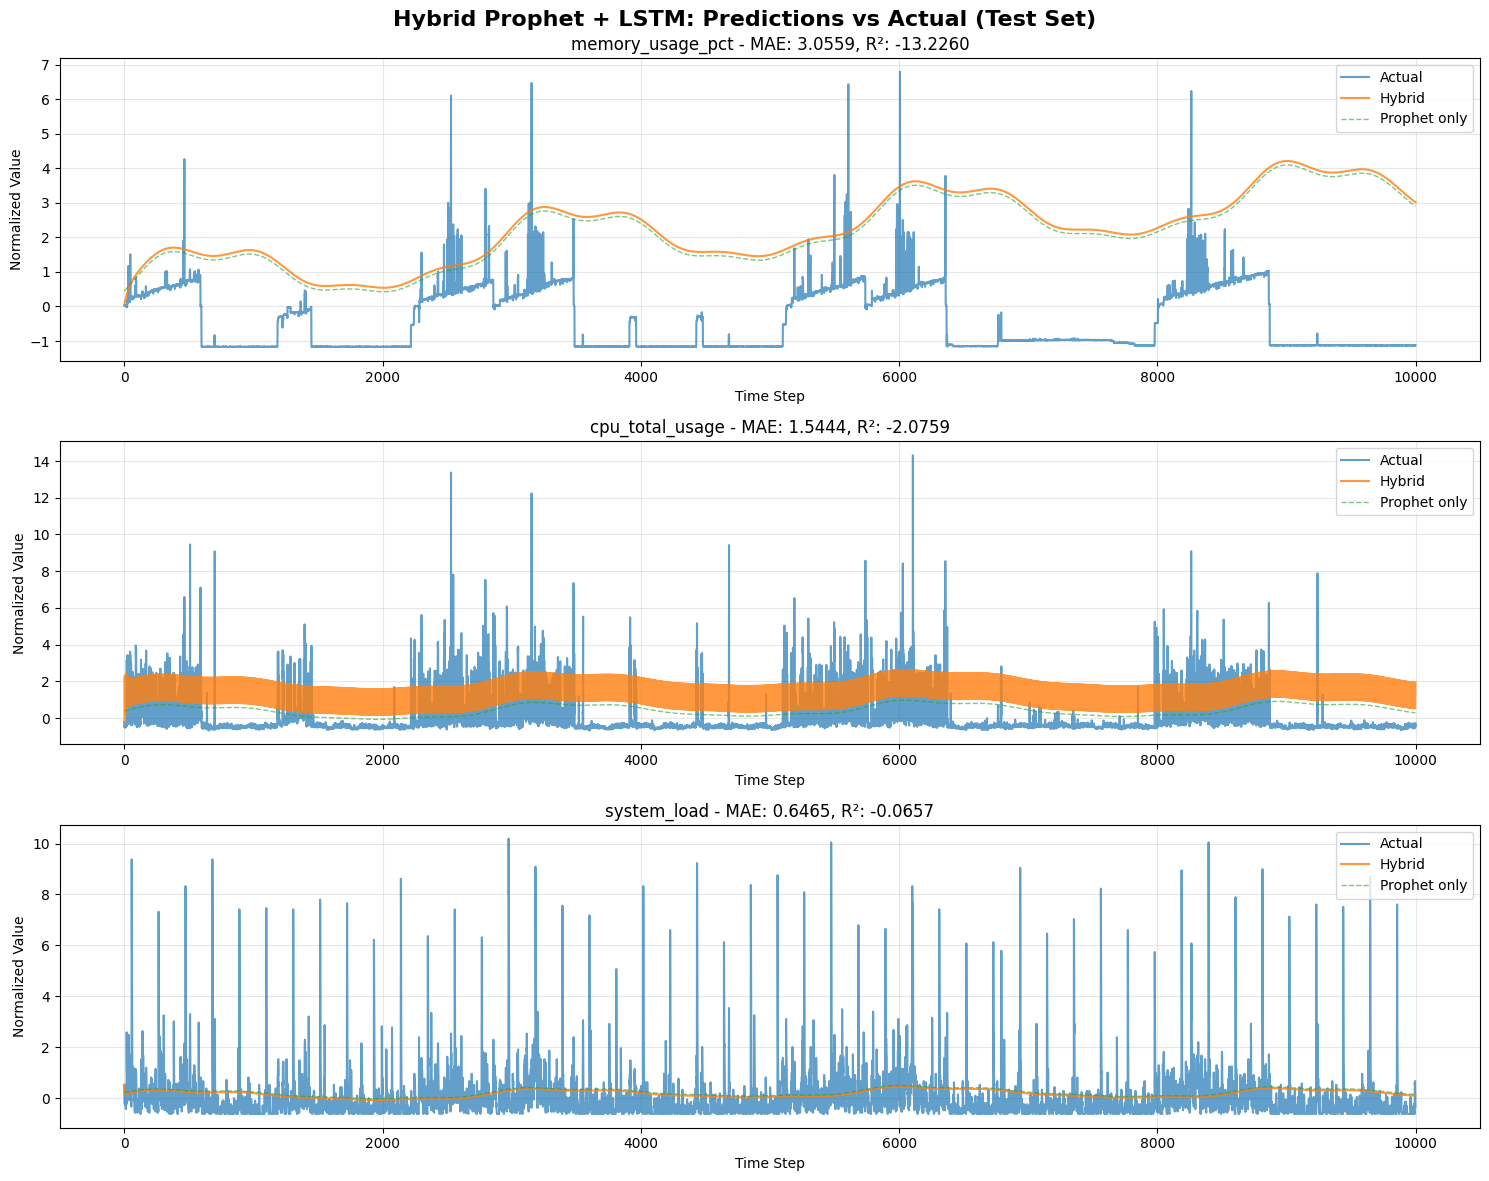

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Hybrid Prophet + LSTM: Predictions vs Actual (Test Set)', fontsize=16, fontweight='bold')

for idx, target in enumerate(TARGETS):
    if target not in prediction_store:
        axes[idx].set_visible(False)
        continue

    y_true = prediction_store[target]['y_true']
    hybrid_pred = prediction_store[target]['hybrid_pred']
    prophet_pred = prediction_store[target]['prophet_pred']

    n_plot = min(10000, len(y_true))
    axes[idx].plot(y_true[:n_plot], label='Actual', alpha=0.7, linewidth=1.5)
    axes[idx].plot(hybrid_pred[:n_plot], label='Hybrid', alpha=0.8, linewidth=1.5)
    axes[idx].plot(prophet_pred[:n_plot], label='Prophet only', alpha=0.6, linewidth=1.0, linestyle='--')
    axes[idx].set_title(
        f"{target} - MAE: {evaluation_results[target]['mae']:.4f}, "
        f"R²: {evaluation_results[target]['r2']:.4f}"
    )
    axes[idx].set_xlabel('Time Step')
    axes[idx].set_ylabel('Normalized Value')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


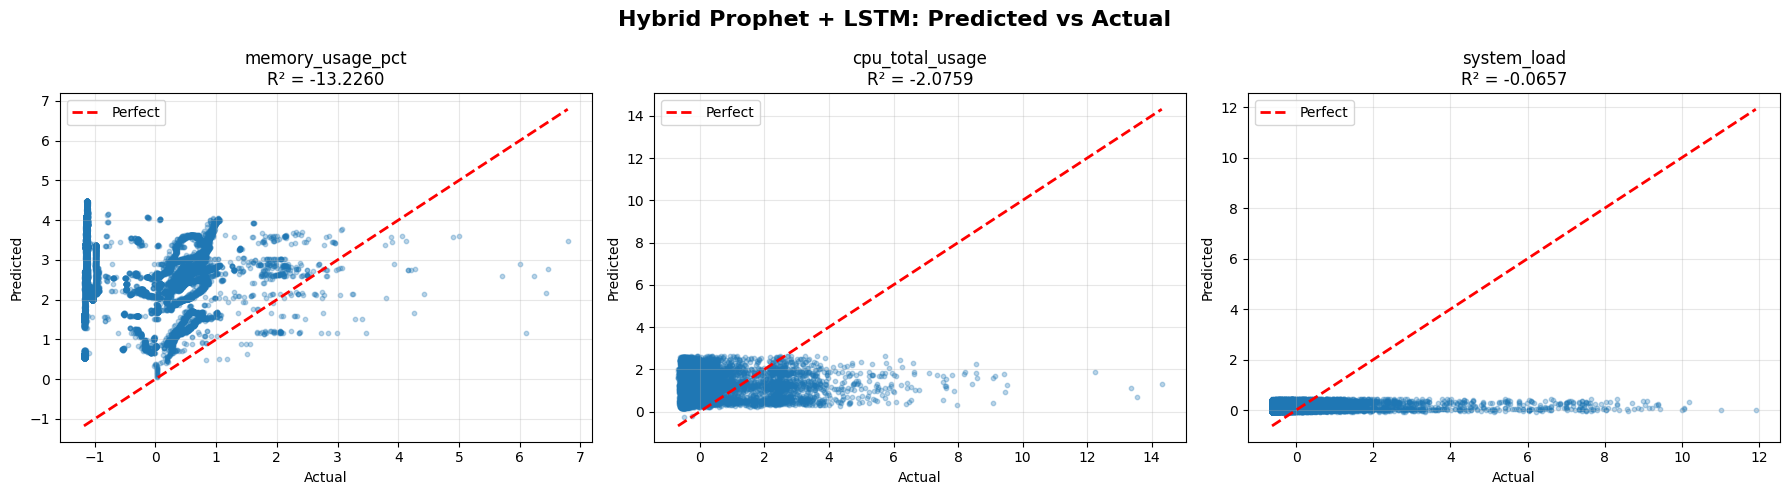

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hybrid Prophet + LSTM: Predicted vs Actual', fontsize=16, fontweight='bold')

for idx, target in enumerate(TARGETS):
    if target not in prediction_store:
        axes[idx].set_visible(False)
        continue

    y_true = prediction_store[target]['y_true']
    hybrid_pred = prediction_store[target]['hybrid_pred']

    axes[idx].scatter(y_true, hybrid_pred, alpha=0.3, s=10)
    min_val = min(y_true.min(), hybrid_pred.min())
    max_val = max(y_true.max(), hybrid_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')

    axes[idx].set_title(f"{target}\nR² = {evaluation_results[target]['r2']:.4f}")
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('Predicted')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


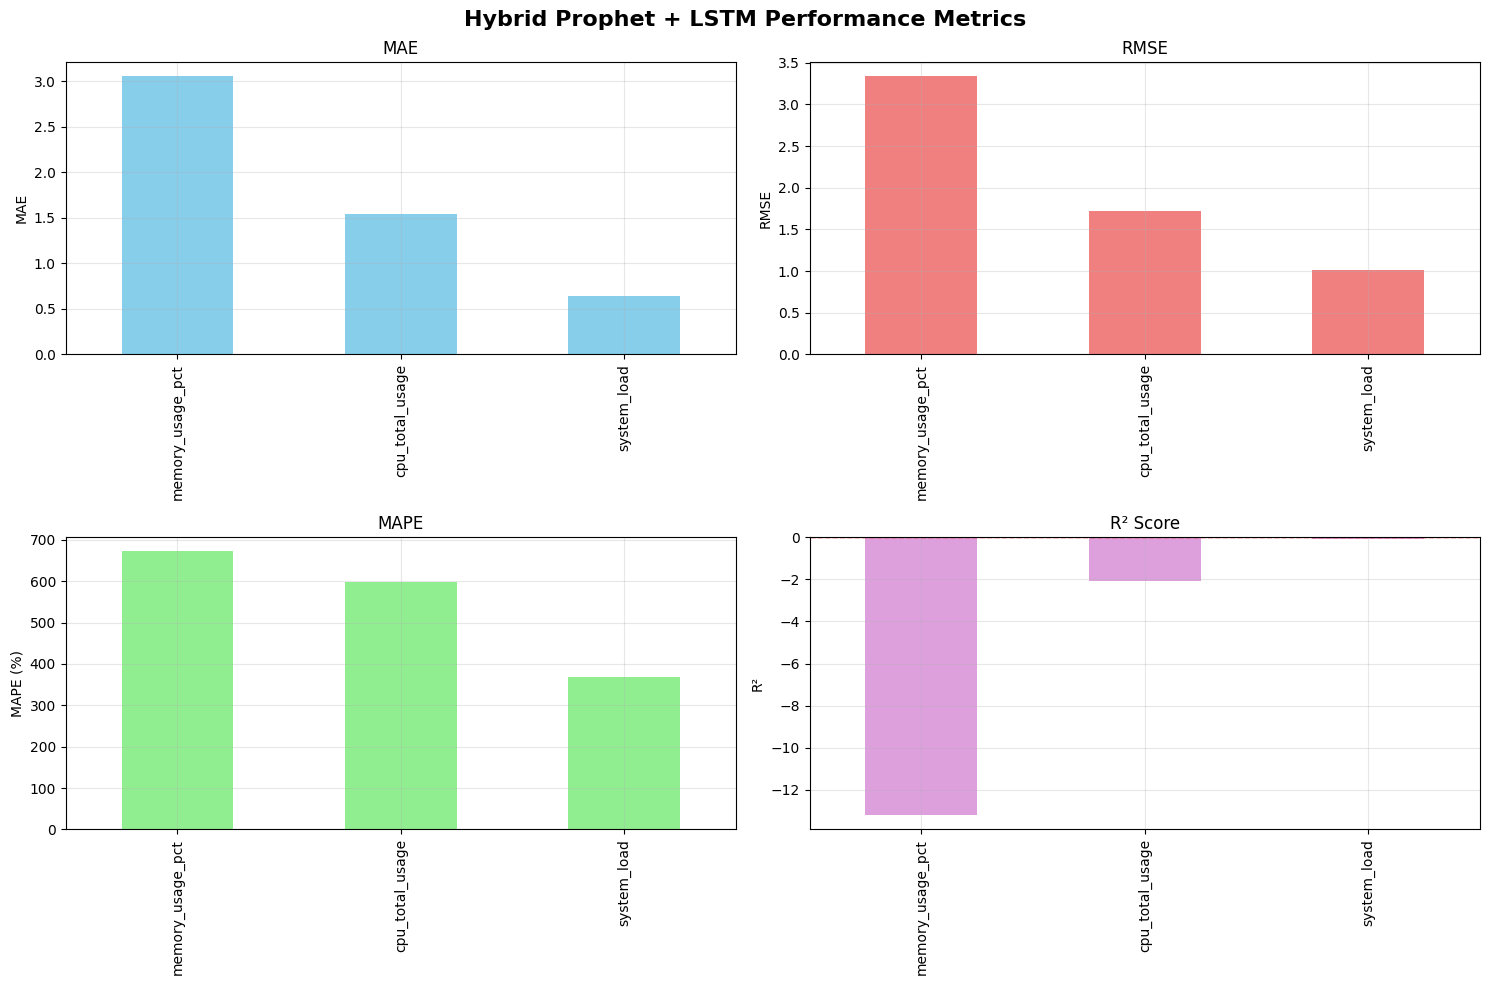

In [9]:
metrics_df = pd.DataFrame(evaluation_results).T

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Hybrid Prophet + LSTM Performance Metrics', fontsize=16, fontweight='bold')

metrics_df['mae'].plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('MAE')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].grid(True, alpha=0.3)

metrics_df['rmse'].plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('RMSE')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].grid(True, alpha=0.3)

metrics_df['mape'].plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('MAPE')
axes[1, 0].set_ylabel('MAPE (%)')
axes[1, 0].grid(True, alpha=0.3)

metrics_df['r2'].plot(kind='bar', ax=axes[1, 1], color='plum')
axes[1, 1].set_title('R² Score')
axes[1, 1].set_ylabel('R²')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
results_payload = {
    'model': 'hybrid_prophet_lstm',
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'targets': detailed_results,
}

save_results(results_payload, 'results_hybrid_prophet_lstm_inference.json')


✓ Results saved: results_hybrid_prophet_lstm_inference.json


'results_hybrid_prophet_lstm_inference.json'